In [3]:
import os
import gzip
import time
import subprocess
import shutil
from io import StringIO
from typing import List, Optional

import pandas as pd
import numpy as np
from tqdm import tqdm
from Bio import Entrez, SeqIO, Phylo
from Bio.SeqRecord import SeqRecord
import matplotlib.pyplot as plt  

In [4]:
# %% [markdown]
# ## User configuration — change these before running

# %%
# Path to VIRION
VIRION_CSV = "virion.csv"   # path to virion.csv
OUTDIR = "virion_bat_cov_output"  # output dir
ENTREZ_EMAIL = "princezarzees5075@gmail.com"  # <<-- SET THIS
ENTREZ_API_KEY = None  # optional

# thresholds (heuristics)
MIN_HOST_NT_LEN = 800      # minimum nt length for host mitogenome / marker
MIN_SPIKE_AA_LEN = 650     # minimum aa length for spike protein
MIN_GENOME_NT_LEN = 20000  # minimum nt length for viral genome fallback

# create dirs
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(os.path.join(OUTDIR, "hosts"), exist_ok=True)
os.makedirs(os.path.join(OUTDIR, "viruses"), exist_ok=True)
os.makedirs(os.path.join(OUTDIR, "alignments"), exist_ok=True)
os.makedirs(os.path.join(OUTDIR, "trees"), exist_ok=True)
os.makedirs(os.path.join(OUTDIR, "metadata"), exist_ok=True)

# Entrez setup
Entrez.email = ENTREZ_EMAIL
if ENTREZ_API_KEY:
    Entrez.api_key = ENTREZ_API_KEY

# helper which
def which(cmd):
    return shutil.which(cmd)

print("mafft:", which("mafft"))
print("iqtree2:", which("iqtree2"))
print("iqtree:", which("iqtree")) 

mafft: /Users/PSLabMonisha/miniforge3/envs/snakemake-tutorial/bin/mafft
iqtree2: None
iqtree: /Users/PSLabMonisha/miniforge3/envs/snakemake-tutorial/bin/iqtree


In [ ]:
# %% [markdown]
# ## Load VIRION and filter for bat × coronaviruses (by TaxID)
# Uses TaxIDs where possible so downstream steps can use `txid<id>` queries.

# %%
print("Loading VIRION...")
# use encoding utf-8-sig to handle BOM if present
df = pd.read_csv(VIRION_CSV, dtype=str, encoding="latin-1")

df.columns = [c.strip() for c in df.columns]
print("Total VIRION rows:", len(df))

# normalize columns we will use
for col in ["HostOrder", "VirusFamily", "HostTaxID", "VirusTaxID", "Host", "NCBIAccession"]:
    if col not in df.columns:
        df[col] = None

df["HostOrder"] = df["HostOrder"].astype(str).str.lower().str.strip()
df["VirusFamily"] = df["VirusFamily"].astype(str).str.lower().str.strip()

df_bat_cov = df[(df["HostOrder"] == "chiroptera") & (df["VirusFamily"] == "coronaviridae")].copy()
print("Filtered bat x coronavirus rows:", len(df_bat_cov))

# Deduplicate by host+virus+accession where possible
df_bat_cov = df_bat_cov.drop_duplicates(subset=["HostTaxID", "VirusTaxID", "NCBIAccession"])
meta_path = os.path.join(OUTDIR, "metadata", "virion_bat_coronavirus_metadata.csv")
df_bat_cov.to_csv(meta_path, index=False)
print("Saved metadata to:", meta_path)

# Ensure TaxIDs are strings (no floats)
df_bat_cov["HostTaxID"] = df_bat_cov["HostTaxID"].astype(str).str.strip().replace("nan", "")
df_bat_cov["VirusTaxID"] = df_bat_cov["VirusTaxID"].astype(str).str.strip().replace("nan", "")

unique_hosts = sorted([x for x in df_bat_cov["HostTaxID"].unique() if x])
unique_viruses = sorted([x for x in df_bat_cov["VirusTaxID"].unique() if x])

print(f"Unique hosts (TaxIDs): {len(unique_hosts)}")
print(f"Unique viruses (TaxIDs): {len(unique_viruses)}")

Loading VIRION...
Total VIRION rows: 834609
Filtered bat x coronavirus rows: 3127
Saved metadata to: virion_bat_cov_output/metadata/virion_bat_coronavirus_metadata.csv
Unique hosts (TaxIDs): 286
Unique viruses (TaxIDs): 260


In [8]:
# %% [markdown]
# ## Entrez helper functions (search & fetch)
# Small wrappers with a safe sleep.

# %%
ENTREZ_SLEEP = 0.34  # ~3 requests per second (be courteous)

def entrez_search_ids(db: str, term: str, retmax: int = 50) -> List[str]:
    try:
        h = Entrez.esearch(db=db, term=term, retmax=retmax, retmode="xml")
        rec = Entrez.read(h)
        h.close()
        time.sleep(ENTREZ_SLEEP)
        return rec.get("IdList", [])
    except Exception as e:
        print("Entrez search failed:", e, "for", db, term)
        return []

def entrez_fetch_text(db: str, id_: str, rettype: str = "fasta", retmode: str = "text") -> Optional[str]:
    try:
        h = Entrez.efetch(db=db, id=id_, rettype=rettype, retmode=retmode)
        txt = h.read()
        h.close()
        time.sleep(ENTREZ_SLEEP)
        return txt
    except Exception as e:
        print("Entrez fetch failed:", e, "for", db, id_)
        return None

def parse_fasta_from_text(txt: str) -> List[SeqRecord]:
    return list(SeqIO.parse(StringIO(txt), "fasta"))

def sanitize_header(s: str) -> str:
    return s.strip().replace(" ", "_").replace("/", "_").replace("|", "_")

In [9]:
# %% [markdown]
# ## Virus fetch: try spike protein first, then genome fallback
# For each VirusTaxID:
# - Search `protein` DB for spike glycoprotein sequences; accept first with length ≥ MIN_SPIKE_AA_LEN
# - If not found, search `nucleotide` DB for complete genomes with length ≥ MIN_GENOME_NT_LEN
# - Label sequence IDs as `virus_<VirusTaxID>`

# %%
def find_spike_or_genome_by_taxid(v_taxid: str,
                                  min_prot_len: int = MIN_SPIKE_AA_LEN,
                                  min_gen_len: int = MIN_GENOME_NT_LEN) -> Optional[SeqRecord]:
    """
    Prefer spike protein (protein DB) for a given virus taxid, else fallback to genome.
    Returns a SeqRecord or None.
    """
    if not v_taxid or v_taxid in ("", "nan"):
        return None
    # search protein (spike)
    q_prot = f"txid{v_taxid}[Organism:exp] AND (spike glycoprotein OR spike protein OR S protein)"
    prot_ids = entrez_search_ids("protein", q_prot, retmax=30)
    for pid in prot_ids:
        txt = entrez_fetch_text("protein", pid, rettype="fasta")
        if not txt:
            continue
        recs = parse_fasta_from_text(txt)
        if not recs:
            continue
        rec = recs[0]
        if len(rec.seq) >= min_prot_len:
            rec.id = f"virus_{v_taxid}"
            rec.description = f"spike|ncbi:{pid}"
            return rec

    # fallback: nucleotide complete genome
    q_gen = f"txid{v_taxid}[Organism:exp] AND complete genome"
    gen_ids = entrez_search_ids("nucleotide", q_gen, retmax=30)
    for gid in gen_ids:
        txt = entrez_fetch_text("nucleotide", gid, rettype="fasta")
        if not txt:
            continue
        recs = parse_fasta_from_text(txt)
        if not recs:
            continue
        rec = recs[0]
        if len(rec.seq) >= min_gen_len:
            rec.id = f"virus_{v_taxid}"
            rec.description = f"genome|ncbi:{gid}"
            return rec

    return None

In [10]:
# %% [markdown]
# ## Host fetch: try mitochondrial markers (using host name from VIRION)
# For each HostTaxID we take the first host name available in VIRION rows and query mitochondrion/cytb/COI.
# Label host seq as `host_<HostTaxID>`

# %%
def find_host_mitogenome_by_name(host_name: str, host_taxid: str, min_len: int = MIN_HOST_NT_LEN) -> Optional[SeqRecord]:
    if not host_name or host_name in ("", "nan"):
        return None
    queries = [
        f'"{host_name}"[Organism] AND mitochondrion[filter] AND complete genome',
        f'"{host_name}"[Organism] AND mitochondrion[filter] AND (cytochrome b[Title] OR cytb[Title])',
        f'"{host_name}"[Organism] AND (cytochrome b[Title] OR cytb[Title])',
        f'"{host_name}"[Organism] AND (COI OR "cytochrome c oxidase subunit I")[Title]',
        f'"{host_name}"[Organism] AND mitochondrion[filter]'
    ]
    for q in queries:
        ids = entrez_search_ids("nucleotide", q, retmax=10)
        for id_ in ids:
            txt = entrez_fetch_text("nucleotide", id_, rettype="fasta")
            if not txt:
                continue
            recs = parse_fasta_from_text(txt)
            if not recs:
                continue
            rec = recs[0]
            if len(rec.seq) >= min_len:
                rec.id = f"host_{host_taxid}"
                rec.description = f"{host_name}|ncbi:{id_}"
                return rec
    return None

In [11]:
# %% [markdown]
# ## Fetch virus sequences (spike-first) for all unique VirusTaxIDs
# This may take a while depending on how many taxa; progress prints provided.

# %%
viral_records = []
failed_virus_taxids = []
print("Fetching virus sequences (spike preferred, genome fallback)...")
for v_tax in tqdm(unique_viruses, desc="viruses"):
    try:
        rec = find_spike_or_genome_by_taxid(v_tax)
        if rec:
            viral_records.append(rec)
        else:
            failed_virus_taxids.append(v_tax)
            # print minimal log to not spam
    except Exception as e:
        print("Error fetching virus taxid", v_tax, "->", e)
        failed_virus_taxids.append(v_tax)

viruses_fasta = os.path.join(OUTDIR, "viruses", "viruses_sequences.fasta")
if viral_records:
    SeqIO.write(viral_records, viruses_fasta, "fasta")
    print("Wrote virus FASTA to", viruses_fasta)
else:
    print("No viral sequences obtained.")

if failed_virus_taxids:
    print("Virus TaxIDs with no sequence found (count):", len(failed_virus_taxids))


Fetching virus sequences (spike preferred, genome fallback)...


viruses:  16%|█▌        | 42/260 [01:20<15:39,  4.31s/it]

Entrez search failed: Search Backend failed: 		
 for nucleotide txid2042542[Organism:exp] AND complete genome


viruses:  20%|█▉        | 51/260 [02:13<32:31,  9.34s/it]

Entrez search failed: Search Backend failed: 		
 for nucleotide txid2042551[Organism:exp] AND complete genome


...

Entrez search failed: Search Backend failed: 		
 for nucleotide txid2042565[Organism:exp] AND complete genome


viruses:  29%|██▉       | 75/260 [03:43<10:34,  3.43s/it]

Entrez search failed: Search Backend failed: 		
 for nucleotide txid2042577[Organism:exp] AND complete genome


viruses: 100%|██████████| 260/260 [10:02<00:00,  2.32s/it]

Wrote virus FASTA to virion_bat_cov_output/viruses/viruses_sequences.fasta
Virus TaxIDs with no sequence found (count): 166


In [12]:
# %% [markdown]
# ## Fetch host sequences (mitochondrial markers) for hosts where name available
# Use the host name from the VIRION rows corresponding to that HostTaxID.

# %%
host_records = []
failed_host_taxids = []
print("Fetching host mitochondrial/marker sequences...")
for h_tax in tqdm(unique_hosts, desc="hosts"):
    subset = df_bat_cov[df_bat_cov["HostTaxID"] == h_tax]
    if subset.empty:
        failed_host_taxids.append(h_tax)
        continue
    host_name = subset.iloc[0]["Host"]
    try:
        rec = find_host_mitogenome_by_name(host_name, h_tax)
        if rec:
            host_records.append(rec)
        else:
            failed_host_taxids.append(h_tax)
    except Exception as e:
        print("Error fetching host", h_tax, host_name, "->", e)
        failed_host_taxids.append(h_tax)

hosts_fasta = os.path.join(OUTDIR, "hosts", "hosts_sequences.fasta")
if host_records:
    SeqIO.write(host_records, hosts_fasta, "fasta")
    print("Wrote host FASTA to", hosts_fasta)
else:
    print("No host sequences obtained.")

if failed_host_taxids:
    print("Host TaxIDs with no host sequence found (count):", len(failed_host_taxids))


Fetching host mitochondrial/marker sequences...


hosts:   9%|▊         | 25/286 [01:56<14:16,  3.28s/it] 

Entrez search failed: Search Backend failed: 		
 for nucleotide "vespadelus regulus"[Organism] AND mitochondrion[filter]


hosts: 100%|██████████| 286/286 [16:38<00:00,  3.49s/it]

Wrote host FASTA to virion_bat_cov_output/hosts/hosts_sequences.fasta
Host TaxIDs with no host sequence found (count): 53


In [13]:
# %% [markdown]
# ## Alignment with MAFFT (fail if MAFFT missing)
# Align virus sequences (spike proteins are amino acids; genomes are nucleotides).
# We'll detect whether the virus file is AA or NT by inspecting the first record.

# %%
def run_mafft(in_fasta: str, out_fasta: str) -> bool:
    mafft_path = which("mafft")
    if mafft_path is None:
        print("MAFFT not found on PATH. Install mafft (bioconda: mafft) and try again.")
        return False
    cmd = [mafft_path, "--auto", os.path.abspath(in_fasta)]
    print("Running:", " ".join(cmd))
    with open(out_fasta, "w") as outfh:
        subprocess.run(cmd, stdout=outfh, stderr=subprocess.PIPE, check=True)
    print("MAFFT wrote", out_fasta)
    return True

def is_protein_fasta(fasta_path: str) -> bool:
    rec = next(SeqIO.parse(fasta_path, "fasta"))
    alpha = set(str(rec.seq).upper())
    return not alpha.issubset(set("ATCGUN-"))

# virus alignment
virus_aln = os.path.join(OUTDIR, "alignments", "viruses_aligned.fasta")
if os.path.exists(viruses_fasta) and os.path.getsize(viruses_fasta) > 0:
    try:
        ok = run_mafft(viruses_fasta, virus_aln)
        if not ok:
            raise RuntimeError("MAFFT failed or missing")
    except Exception as e:
        raise RuntimeError("MAFFT alignment for viruses failed: " + str(e))
else:
    raise RuntimeError("No virus fasta available; cannot align")

# host alignment (optional if we have host sequences)
host_aln = os.path.join(OUTDIR, "alignments", "hosts_aligned.fasta")
if os.path.exists(hosts_fasta) and os.path.getsize(hosts_fasta) > 0:
    try:
        ok = run_mafft(hosts_fasta, host_aln)
        if not ok:
            print("MAFFT failed for hosts; copying raw sequences as fallback")
            shutil.copy(hosts_fasta, host_aln)
    except Exception as e:
        print("MAFFT failed for hosts:", e)
        shutil.copy(hosts_fasta, host_aln)
else:
    print("No hosts fasta available; skipping host alignment")


Running: /Users/PSLabMonisha/miniforge3/envs/snakemake-tutorial/bin/mafft --auto /Users/PSLabMonisha/Desktop/simulation_exps/virion/virion_bat_cov_output/viruses/viruses_sequences.fasta
MAFFT wrote virion_bat_cov_output/alignments/viruses_aligned.fasta
Running: /Users/PSLabMonisha/miniforge3/envs/snakemake-tutorial/bin/mafft --auto /Users/PSLabMonisha/Desktop/simulation_exps/virion/virion_bat_cov_output/hosts/hosts_sequences.fasta
MAFFT wrote virion_bat_cov_output/alignments/hosts_aligned.fasta


In [14]:
def find_iqtree_binary() -> Optional[str]:
    for name in ("iqtree2", "iqtree"):
        p = which(name)
        if p:
            return name
    return None

IQCMD = find_iqtree_binary()
if IQCMD is None:
    raise RuntimeError("IQ-TREE (iqtree2 or iqtree) not found on PATH. Install (bioconda: iqtree) and try again.")
print("Using IQ-TREE binary:", IQCMD)

def run_iqtree(aln_path: str, prefix: str, is_protein: bool=False) -> str:
    aln_abs = os.path.abspath(aln_path)
    workdir = os.path.dirname(aln_abs)
    cmd = [IQCMD, "-s", aln_abs, "-m", "MFP", "-bb", "1000", "-alrt", "1000", "-nt", "AUTO", "-pre", prefix]
    if is_protein:
        cmd.extend(["-st", "AA"])
    print("Running IQ-TREE:", " ".join(cmd))
    subprocess.run(cmd, cwd=workdir, check=True)
    treefile = os.path.join(workdir, prefix + ".treefile")
    if os.path.exists(treefile):
        return treefile
    alt = os.path.join(workdir, prefix + ".contree")
    if os.path.exists(alt):
        return alt
    raise RuntimeError("IQ-TREE did not produce a treefile for " + aln_path)

# Decide if viral alignment is protein
virus_is_protein = is_protein_fasta(virus_aln)
print("Virus alignment detected as protein?" , virus_is_protein)
virus_treefile = run_iqtree(virus_aln, "virion_viruses_aln", is_protein=virus_is_protein)
shutil.copy(virus_treefile, os.path.join(OUTDIR, "trees", "viruses_tree.newick"))
print("Virus tree saved to", os.path.join(OUTDIR, "trees", "viruses_tree.newick"))

# host tree (if aligned successfully)
if os.path.exists(host_aln):
    try:
        host_treefile = run_iqtree(host_aln, "virion_hosts_aln", is_protein=False)
        shutil.copy(host_treefile, os.path.join(OUTDIR, "trees", "hosts_tree.newick"))
        print("Host tree saved to", os.path.join(OUTDIR, "trees", "hosts_tree.newick"))
    except Exception as e:
        print("IQ-TREE failed for host alignment:", e)

Using IQ-TREE binary: iqtree
Virus alignment detected as protein? True
Running IQ-TREE: iqtree -s /Users/PSLabMonisha/Desktop/simulation_exps/virion/virion_bat_cov_output/alignments/viruses_aligned.fasta -m MFP -bb 1000 -alrt 1000 -nt AUTO -pre virion_viruses_aln -st AA
IQ-TREE version 3.0.1 for MacOS ARM 64-bit built Jul  9 2025
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Host:    CS-5095.local (SSE4.2, 24 GB RAM)
Command: iqtree -s /Users/PSLabMonisha/Desktop/simulation_exps/virion/virion_bat_cov_output/alignments/viruses_aligned.fasta -m MFP -bb 1000 -alrt 1000 -nt AUTO -pre virion_viruses_aln -st AA
Seed:    456220 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Tue Sep 23 22:51:09 2025
Kernel:  SSE2 - auto-detect threads (10 CPU cores detected)

Reading alignment file /Users/PSLabMonisha/Desktop/simulation_exps

In [15]:
# %%
def plot_and_save_tree(treefile: str, out_png: str, title: str=""):
    try:
        tree = Phylo.read(treefile, "newick")
        fig = plt.figure(figsize=(10, max(6, len(tree.get_terminals()) * 0.2)))
        ax = fig.add_subplot(1, 1, 1)
        Phylo.draw(tree, axes=ax, do_show=False)
        if title:
            plt.title(title)
        plt.tight_layout()
        plt.savefig(out_png, dpi=200)
        plt.close(fig)
        print("Saved tree plot to", out_png)
    except Exception as e:
        print("Failed to plot tree", treefile, "->", e)

if os.path.exists(os.path.join(OUTDIR, "trees", "viruses_tree.newick")):
    plot_and_save_tree(os.path.join(OUTDIR, "trees", "viruses_tree.newick"),
                       os.path.join(OUTDIR, "trees", "viruses_tree.png"),
                       title="VIRION: Bat Coronavirus Phylogeny")

if os.path.exists(os.path.join(OUTDIR, "trees", "hosts_tree.newick")):
    plot_and_save_tree(os.path.join(OUTDIR, "trees", "hosts_tree.newick"),
                       os.path.join(OUTDIR, "trees", "hosts_tree.png"),
                       title="VIRION: Host (mitochondrial) Phylogeny")

Saved tree plot to virion_bat_cov_output/trees/viruses_tree.png
Saved tree plot to virion_bat_cov_output/trees/hosts_tree.png


In [18]:
# %%
import pandas as pd
from Bio import Phylo

# Paths to the newick trees
host_treefile = "virion_bat_cov_output/trees/hosts_tree.newick"
virus_treefile = "virion_bat_cov_output/trees/viruses_tree.newick"

# Load edgelist
edgelist = pd.read_csv("edgelist.csv", dtype=str)

# Get host and virus leaves from trees
host_tree = Phylo.read(host_treefile, "newick")
virus_tree = Phylo.read(virus_treefile, "newick")

host_leaves = sorted([t.name for t in host_tree.get_terminals()])
virus_leaves = sorted([t.name for t in virus_tree.get_terminals()])

print("Hosts in tree:", host_leaves)
print("Viruses in tree:", virus_leaves)

# Format IDs to match leaves
edgelist["Host_fmt"] = "host_" + edgelist["HostTaxID"].astype(str).str.strip()
edgelist["Virus_fmt"] = "virus_" + edgelist["VirusTaxID"].astype(str).str.strip()

# Explode AssocID if multiple
edgelist_filtered = edgelist.assign(
    AssocID = edgelist["AssocID"].str.split(",")
).explode("AssocID")

# Keep only hosts and viruses that are in the trees
edgelist_filtered = edgelist_filtered[
    edgelist_filtered["Host_fmt"].isin(host_leaves) &
    edgelist_filtered["Virus_fmt"].isin(virus_leaves)
]

# Initialize matrix with zeros
interaction_matrix = pd.DataFrame(
    0,
    index=virus_leaves,
    columns=host_leaves,
    dtype=int
)

# Fill in ones for interactions present in edgelist
for _, row in edgelist_filtered.iterrows():
    interaction_matrix.at[row["Virus_fmt"], row["Host_fmt"]] = 1

# Save to CSV
interaction_matrix.to_csv("interaction_matrix_tree_leaves.csv")

print("Interaction matrix shape:", interaction_matrix.shape)
interaction_matrix.head()


Hosts in tree: ['host_105273', 'host_105295', 'host_109478', 'host_109480', 'host_109481', 'host_109482', 'host_109485', 'host_110938', 'host_110941', 'host_118856', 'host_1195082', 'host_1207989', 'host_124751', 'host_124756', 'host_132908', 'host_1381355', 'host_138695', 'host_138977', 'host_138979', 'host_1410044', 'host_1434095', 'host_143942', 'host_148061', 'host_148089', 'host_148094', 'host_153297', 'host_155035', 'host_155915', 'host_157961', 'host_159330', 'host_159858', 'host_160974', 'host_1633875', 'host_166054', 'host_169756', 'host_170233', 'host_175524', 'host_177160', 'host_177162', 'host_177185', 'host_178895', 'host_186990', 'host_186991', 'host_187003', 'host_187007', 'host_187008', 'host_187011', 'host_187014', 'host_187017', 'host_1884717', 'host_188568', 'host_188569', 'host_188570', 'host_188571', 'host_188572', 'host_1898386', 'host_1898389', 'host_1898393', 'host_1911917', 'host_192403', 'host_196296', 'host_196297', 'host_196700', 'host_196889', 'host_2015597

,host_105273,host_105295,host_109478,host_109480,host_109481,host_109482,host_109485,host_110938,host_110941,host_118856,...,host_9423,host_9430,host_9433,host_9435,host_9438,host_94956,host_94961,host_98922,host_999321,host_999964
virus_11137,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
virus_1244203,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
virus_1335626,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
virus_1508220,1,1,1,1,1,0,0,0,0,0,...,0,1,1,0,1,0,0,1,1,1
virus_1805463,1,1,0,0,0,0,0,1,0,1,...,0,0,0,0,0,1,0,0,0,0


In [19]:
count = interaction_matrix.values.sum()
print("Total interactions (1s) in matrix:", count)

Total interactions (1s) in matrix: 549


Host leaves (233): ['host_105273', 'host_105295', 'host_258946', 'host_187011', 'host_375553', 'host_51300', 'host_246814', 'host_294653', 'host_59473', 'host_109478']...
Virus leaves (94): ['virus_11137', 'virus_1244203', 'virus_3433754', 'virus_3433753', 'virus_3119326', 'virus_3433752', 'virus_1906673', 'virus_3433785', 'virus_2971263', 'virus_3433786']...
Host mapping: 229 success, 4 failures
Virus mapping: 73 success, 21 failures
Host monophyly summary: {'tested_groups': 11, 'monophyletic_groups': 8, 'non_mono_count': 3}
Virus monophyly summary: {'tested_groups': 3, 'monophyletic_groups': 1, 'non_mono_count': 2}


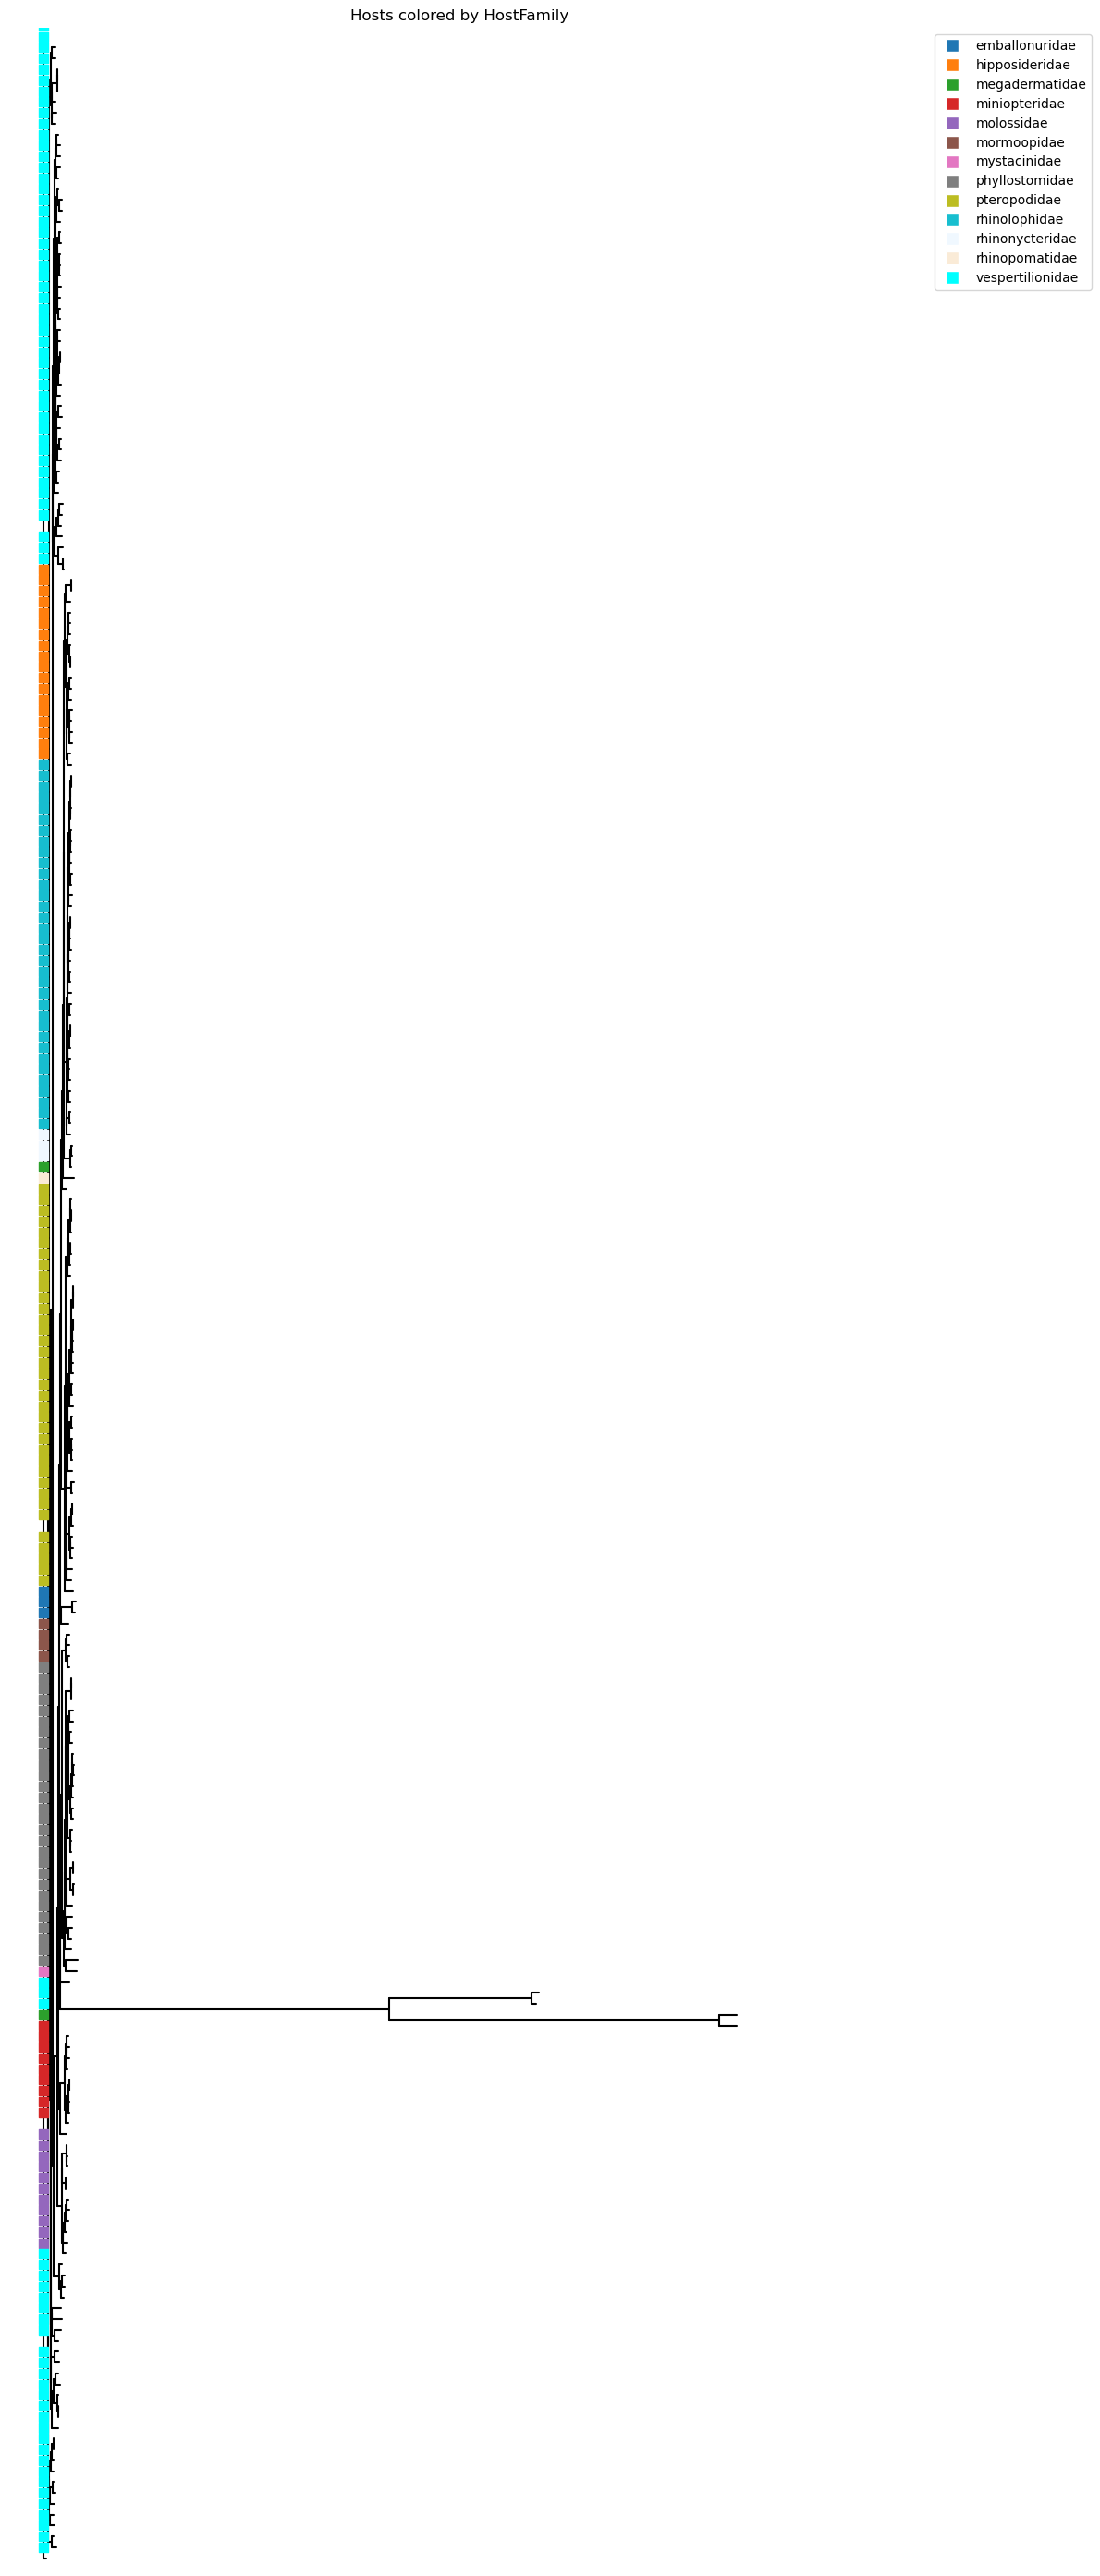

Saved tree figure to host_tree_colored_blocks.png


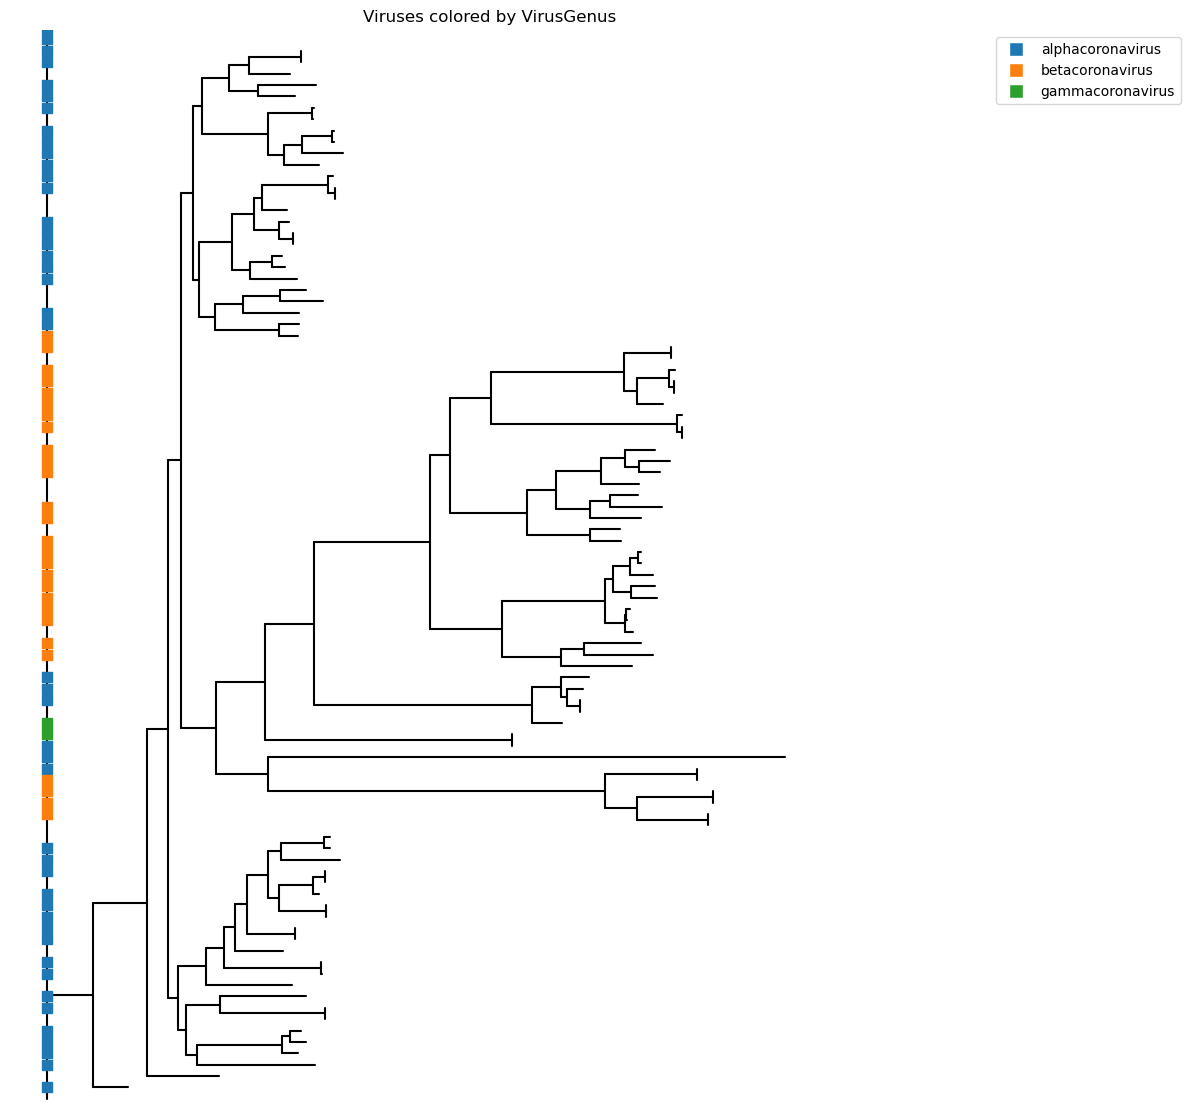

Saved tree figure to virus_tree_colored_blocks.png
Reports saved: host_nonmonophyletic_report.json, virus_nonmonophyletic_report.json


In [13]:
# %% [markdown]
# Sanity check: compare phylogeny leaves to taxonomy

# %%
import os
import json
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
from Bio import Phylo
from matplotlib import colors as mcolors

# %% [markdown]
# Config — set paths to your files

# %%
HOST_TAXONOMY_CSV = "taxonomy_host.csv"
VIRUS_TAXONOMY_CSV = "taxonomy_virus.csv"
HOST_TREE = "virion_bat_cov_output/trees/hosts_tree.newick"
VIRUS_TREE = "virion_bat_cov_output/trees/viruses_tree.newick"

HOST_RANK = "HostFamily"   # e.g., 'HostFamily' or 'HostGenus'
VIRUS_RANK = "VirusGenus" # e.g., 'VirusGenus' or 'VirusFamily'

# %% [markdown]
# Load taxonomies

# %%
host_tax = pd.read_csv(HOST_TAXONOMY_CSV, dtype=str).fillna("").drop_duplicates("HostTaxID")
virus_tax = pd.read_csv(VIRUS_TAXONOMY_CSV, dtype=str).fillna("").drop_duplicates("VirusTaxID")

host_lookup = host_tax.set_index("HostTaxID").to_dict("index")
virus_lookup = virus_tax.set_index("VirusTaxID").to_dict("index")

def normalize_taxon(value: str) -> str:
    """Normalize taxon names: strip whitespace and make lowercase."""
    return value.strip().lower() if value else ""

def get_host_tax_field(taxid: str, field: str):
    return normalize_taxon(host_lookup.get(str(taxid), {}).get(field, ""))

def get_virus_tax_field(taxid: str, field: str):
    return normalize_taxon(virus_lookup.get(str(taxid), {}).get(field, ""))

# %% [markdown]
# Load trees

# %%
host_tree = Phylo.read(HOST_TREE, "newick")
virus_tree = Phylo.read(VIRUS_TREE, "newick")

host_leaves = [t.name for t in host_tree.get_terminals()]
virus_leaves = [t.name for t in virus_tree.get_terminals()]

print(f"Host leaves ({len(host_leaves)}): {host_leaves[:10]}{'...' if len(host_leaves)>10 else ''}")
print(f"Virus leaves ({len(virus_leaves)}): {virus_leaves[:10]}{'...' if len(virus_leaves)>10 else ''}")

# %% [markdown]
# Map leaf names -> taxonomy rank

# %%
def map_leaves(leaves, get_tax_field, rank_col):
    leaf2taxon, failures = {}, []
    for leaf in leaves:
        if "_" in leaf:
            taxid = leaf.split("_", 1)[1]
            mapped = get_tax_field(taxid, rank_col)
            if mapped:
                leaf2taxon[leaf] = mapped
            else:
                failures.append(leaf)
        else:
            failures.append(leaf)
    return leaf2taxon, failures

host_leaf2tax, host_failures = map_leaves(host_leaves, get_host_tax_field, HOST_RANK)
virus_leaf2tax, virus_failures = map_leaves(virus_leaves, get_virus_tax_field, VIRUS_RANK)

print(f"Host mapping: {len(host_leaf2tax)} success, {len(host_failures)} failures")
print(f"Virus mapping: {len(virus_leaf2tax)} success, {len(virus_failures)} failures")

# %% [markdown]
# Monophyly test

# %%
def test_monophyly(tree, leaf2taxon):
    taxon2leaves = defaultdict(set)
    for leaf, tax in leaf2taxon.items():
        taxon2leaves[tax].add(leaf)

    results, non_mono = {}, {}
    tested, mono_count = 0, 0
    for taxon, leaves in taxon2leaves.items():
        if len(leaves) < 2:
            results[taxon] = {"n_leaves": len(leaves), "monophyletic": None}
            continue
        tested += 1
        try:
            terminals = [next(t for t in tree.get_terminals() if t.name == leaf) for leaf in leaves]
            mrca = tree.common_ancestor(terminals)
            mrca_term_names = {t.name for t in mrca.get_terminals()}
            is_mono = set(leaves) == mrca_term_names
            results[taxon] = {"n_leaves": len(leaves), "monophyletic": is_mono, "mrca_size": len(mrca_term_names)}
            if is_mono:
                mono_count += 1
            else:
                outsiders = sorted(list(mrca_term_names - set(leaves)))
                missing = sorted(list(set(leaves) - mrca_term_names))
                non_mono[taxon] = {"leaves": sorted(list(leaves)), "outsiders": outsiders, "missing": missing}
        except StopIteration:
            results[taxon] = {"n_leaves": len(leaves), "monophyletic": None, "error": "leaf_not_found"}

    summary = {"tested_groups": tested, "monophyletic_groups": mono_count, "non_mono_count": tested - mono_count}
    return results, non_mono, summary

host_results, host_nonmono, host_summary = test_monophyly(host_tree, host_leaf2tax)
virus_results, virus_nonmono, virus_summary = test_monophyly(virus_tree, virus_leaf2tax)

print("Host monophyly summary:", host_summary)
print("Virus monophyly summary:", virus_summary)

# %% [markdown]
# Plot trees with colored blocks at tips

# %%
def plot_tree_with_blocks(tree, leaf2taxon, outpng, title="Tree"):
    taxa = sorted(set(leaf2taxon.values()))
    base_colors = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
    cmap = {tax: base_colors[i % len(base_colors)] for i, tax in enumerate(taxa)}

    fig, ax = plt.subplots(figsize=(12, max(6, len(tree.get_terminals()) * 0.12)))

    # Draw tree without tip labels
    Phylo.draw(tree, axes=ax, do_show=False, show_confidence=False, label_func=lambda x: "")

    # Map terminal positions
    terminals = tree.get_terminals()
    y_positions = {t.name: i for i, t in enumerate(terminals)}

    # Draw colored blocks
    for leaf in terminals:
        tax = leaf2taxon.get(leaf.name)
        if tax:
            ax.scatter(0, y_positions[leaf.name], color=cmap[tax], s=50, marker="s", zorder=10)

    # Legend (all taxa)
    legend_items = [plt.Line2D([0], [0], marker='s', color='w', label=tax,
                               markerfacecolor=cmap[tax], markersize=10) for tax in taxa]
    ax.legend(handles=legend_items, bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(outpng, dpi=200)
    plt.show()
    print("Saved tree figure to", outpng)

plot_tree_with_blocks(host_tree, host_leaf2tax, "host_tree_colored_blocks.png", title=f"Hosts colored by {HOST_RANK}")
plot_tree_with_blocks(virus_tree, virus_leaf2tax, "virus_tree_colored_blocks.png", title=f"Viruses colored by {VIRUS_RANK}")

# %% [markdown]
# Save reports

# %%
with open("host_nonmonophyletic_report.json", "w") as f:
    json.dump(host_nonmono, f, indent=2)
with open("virus_nonmonophyletic_report.json", "w") as f:
    json.dump(virus_nonmono, f, indent=2)

print("Reports saved: host_nonmonophyletic_report.json, virus_nonmonophyletic_report.json")
